# Unit 6 习题课：相关系数与简单线性模型

**主题：CRP 与 HOMA-IR 的关系**

课前请先独立试错完成一遍；课堂用 20 分钟讨论方法选择、假设检查、p 值和 95% CI 的解释；老师随后用 15 分钟讲解。请注意：本任务的重点不是只跑出 p 值，而是完成完整的生物医学数据分析流程。


## 0. 环境准备

运行下面的代码导入常用库。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)


## 1. 提出研究问题

社区成年人代谢健康研究想了解低度炎症指标 CRP 是否与胰岛素抵抗水平 HOMA-IR 有关。

**学生作答区：**

1. 写出主要研究问题。

    社区成年人群中，低度炎症指标 CRP 的水平和胰岛素抵抗水平 HOMA-IR 是否存在统计学关联？若存在，CRP 的变化能否对 HOMA-IR 的变化做出预测？
    
2. 指出主要暴露变量和主要结局变量。

    主要暴露变量：低度炎症指标 CRP（自变量）
    
    主要结局变量：胰岛素抵抗水平 HOMA-IR（因变量）

3. 区分“是否相关”和“能否预测”这两个问题。

    是否相关仅探究两变量有无联动变化趋势；能否预测是明确自变量与因变量，量化前者对后者的预估作用，相关是预测的前提，但相关不等于有良好预测能力

4. 说明本研究为什么不能直接推出因果关系。

    本研究还存在许多其他混杂因素，只能验证相关性，不能推导出因果关系


## 2. 导入数据并理解变量

从 CSV 文件读取数据。


In [2]:
df = pd.read_csv("unit6_crp_homair.csv")

# 学生作答区：查看数据前几行、变量类型和基本摘要
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   participant_id          160 non-null    object 
 1   age                     160 non-null    float64
 2   sex                     160 non-null    object 
 3   bmi                     160 non-null    float64
 4   waist_cm                160 non-null    float64
 5   fasting_glucose_mmol_l  160 non-null    float64
 6   fasting_insulin_uIU_ml  160 non-null    float64
 7   crp_mg_l                160 non-null    float64
 8   homa_ir                 160 non-null    float64
dtypes: float64(7), object(2)
memory usage: 11.4+ KB


,age,bmi,waist_cm,fasting_glucose_mmol_l,fasting_insulin_uIU_ml,crp_mg_l,homa_ir
count,160.000,160.000,160.000,160.000,160.000,160.000,160.000
mean,48.213,26.723,93.213,5.168,12.678,2.377,2.942
std,10.360,4.247,7.343,0.359,7.876,1.422,1.902
min,25.000,18.500,72.200,4.000,3.090,0.490,0.670
25%,40.500,23.875,88.225,4.947,7.340,1.417,1.670
50%,48.400,26.550,92.950,5.190,10.190,1.990,2.365
75%,54.200,30.025,98.825,5.393,15.105,2.792,3.652
max,75.000,37.700,112.700,6.110,44.890,8.330,10.520


## 3. 描述性统计

请描述 CRP 和 HOMA-IR 的均值、标准差、中位数、IQR、最小值和最大值。

**提示：**如果均值明显大于中位数，常提示右偏；很多生物标志物都可能呈右偏分布。

**学生作答区：**用 2 到 3 句话描述两个变量的分布特点。


两个变量的均值都明显大于自身中位数，均呈现右偏分布，符合生物标志物常见的分布特征。

HOMA-IR 的标准差、IQR、极差都比 CRP 更大，说明 HOMA-IR 的整体离散程度更强。

两者样本量均为 160，CRP 取值范围 0.490~8.330mg/L，HOMA-IR 取值范围 0.670~10.520，HOMA-IR 整体水平和波动幅度都更高。

In [3]:
main_vars = ["crp_mg_l", "homa_ir"]

# 学生作答区：完成描述性统计
desc = df[main_vars].describe()
iqr = df[main_vars].quantile(0.75) - df[main_vars].quantile(0.25)
display(desc)
print("IQR如下：")
display(iqr)


,crp_mg_l,homa_ir
count,160.000,160.000
mean,2.377,2.942
std,1.422,1.902
min,0.490,0.670
25%,1.417,1.670
50%,1.990,2.365
75%,2.792,3.652
max,8.330,10.520


IQR如下：


crp_mg_l    1.375
homa_ir     1.982
dtype: float64

## 4. 可视化

绘制 CRP 和 HOMA-IR 的分布图、原始尺度散点图和 log-log 散点图。

**解释问题：** 原始尺度是否近似线性？是否有高值点？log 转换后是否更合理？


原始尺度下数据集中于左下角、随自变量增大离散度升高呈喇叭状异方差，存在大量高值离群点，不满足近似线性条件；经双对数转换后散点分布均匀、方差齐性改善，变量线性关联清晰，采用对数尺度建模更为合理。

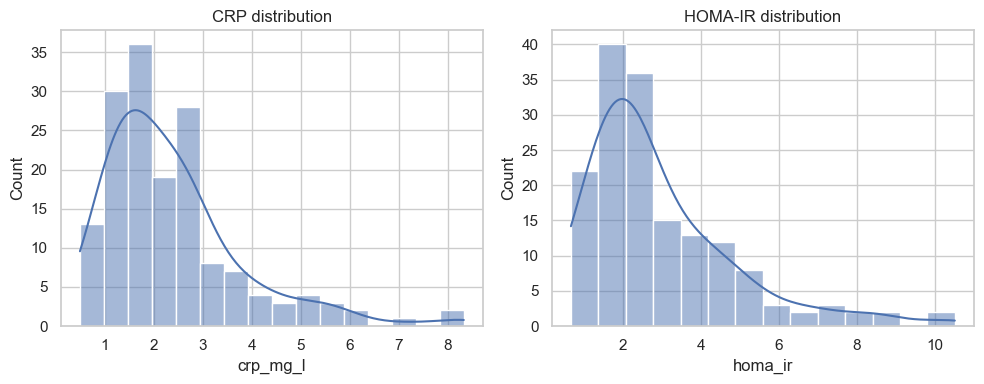

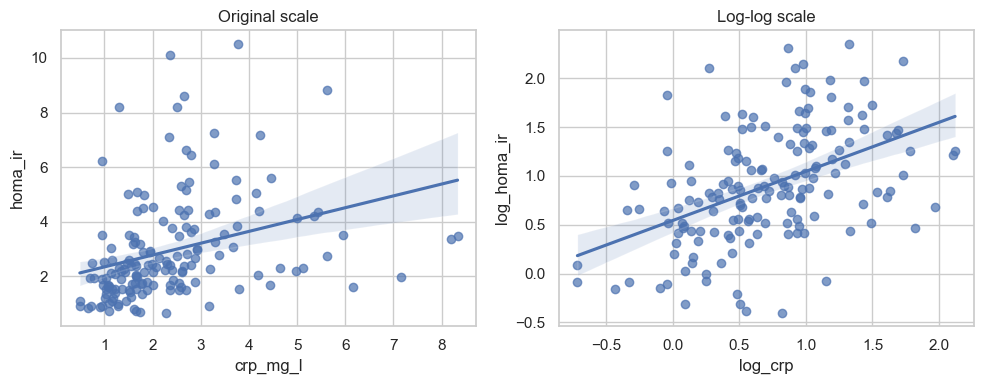

In [4]:
# 学生作答区：分布图
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["crp_mg_l"], kde=True, ax=axes[0])
axes[0].set_title("CRP distribution")
sns.histplot(df["homa_ir"], kde=True, ax=axes[1])
axes[1].set_title("HOMA-IR distribution")
plt.tight_layout()
plt.show()

df["log_crp"] = np.log(df["crp_mg_l"])
df["log_homa_ir"] = np.log(df["homa_ir"])

# 学生作答区：散点图与回归线
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
sns.regplot(data=df, x="crp_mg_l", y="homa_ir", scatter_kws={"alpha": 0.7}, ax=axes2[0])
axes2[0].set_title("Original scale")
sns.regplot(data=df, x="log_crp", y="log_homa_ir", scatter_kws={"alpha": 0.7}, ax=axes2[1])
axes2[1].set_title("Log-log scale")
plt.tight_layout()
plt.show()


## 5. 相关系数、显著性和置信区间

先判断 Pearson 相关是否适合，再计算 Pearson `r`、p 值和 95% CI。然后计算 Spearman 相关作为敏感性分析。

**学生作答区：**

1. 写出 Pearson 相关检验的零假设。
2. 解释 `r` 的方向和大小。
3. 解释 p 值和 95% CI。
4. 如果 95% CI 不包含 0，它和 p < 0.05 有什么关系？
5. 如果结果显著，是否说明关系很强或有因果关系？


1. $H_0: \rho=0$
2. r=0.468，为正方向，属于中等程度线性相关
3. p=0.0000，拒绝原假设，认为r不等于零，两个变量存在显著的线性相关性；95%CI[0.337, 0.581]，不包含0，整体大致落在0.3-0.5中等强度的区间内可以认为存在中等强度的线性相关性
4. 在双侧检验的前提下，95%CI不包含0可以认为等价于p<0.05
5. 不能。统计学显著仅代表相关系数不为0这件事可信度高，不代表相关强度大；且相关仅反映变量共存关联，无法推导因果关系。

In [5]:
def pearson_r_ci(x, y, alpha=0.05):
    r, p = stats.pearsonr(x, y)
    n = len(x)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zcrit = stats.norm.ppf(1 - alpha / 2)
    lo, hi = np.tanh([z - zcrit * se, z + zcrit * se])
    return r, p, lo, hi

# 学生作答区：计算 Pearson 和 Spearman
r, p, lo, hi = pearson_r_ci(df["log_crp"], df["log_homa_ir"])
rho, p_s = stats.spearmanr(df["crp_mg_l"], df["homa_ir"])
print(f"Pearson r = {r:.3f}, 95% CI [{lo:.3f}, {hi:.3f}], p = {p:.4f}")
print(f"Spearman rho = {rho:.3f}, p = {p_s:.4f}")


Pearson r = 0.468, 95% CI [0.337, 0.581], p = 0.0000
Spearman rho = 0.500, p = 0.0000


## 6. 简单线性回归模型

拟合原始尺度模型和 log 转换模型。重点解释斜率系数、p 值和 95% CI。

**学生作答区：**

1. 原始模型中，CRP 每增加 1 mg/L，HOMA-IR 平均变化多少？
2. 斜率系数的 95% CI 如何解释？
3. 斜率 CI 不包含 0 与 p < 0.05 有什么关系？
4. log-log 模型中的系数还能不能按原单位直接解释？


1. CRP 每增加 1 mg/L，HOMA-IR 平均增加 0.4337
2. 斜率 95%CI[0.235, 0.632]，代表有95%的信心认为总体真实斜率落在该区间，且区间全为正数，说明 CRP 对 HOMA-IR 存在正向预测效应
3. 在双侧检验的前提下，95%CI不包含0可以认为等价于p<0.05
4. 不能，变量取对数都无量纲，无法用原始变量单位直接解释绝对增量

In [6]:
# 学生作答区：拟合模型
model_raw = smf.ols("homa_ir ~ crp_mg_l", data=df).fit()
model_log = smf.ols("log_homa_ir ~ log_crp", data=df).fit()
print(model_raw.summary())
print(model_log.summary())
model_log.conf_int()


                            OLS Regression Results                            
Dep. Variable:                homa_ir   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     18.57
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           2.86e-05
Time:                        10:17:02   Log-Likelihood:                -320.46
No. Observations:                 160   AIC:                             644.9
Df Residuals:                     158   BIC:                             651.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9109      0.279      6.860      0.0

,0,1
Intercept,0.408,0.677
log_crp,0.354,0.653


## 7. 模型假设检查

检查残差 vs 拟合值图、Q-Q 图和高影响点。


残差均匀分布在水平线 y=0上下，并且随着拟合值的增加，残差的离散程度保持恒定，没有出现漏斗形或喇叭形，同时也无明显高影响点。同时残差的分布是基本符合正态分布的。

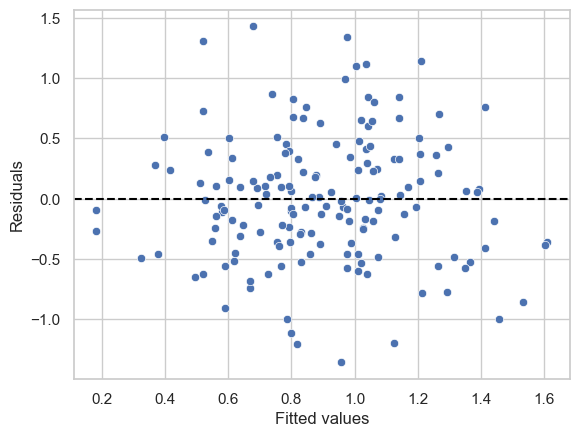

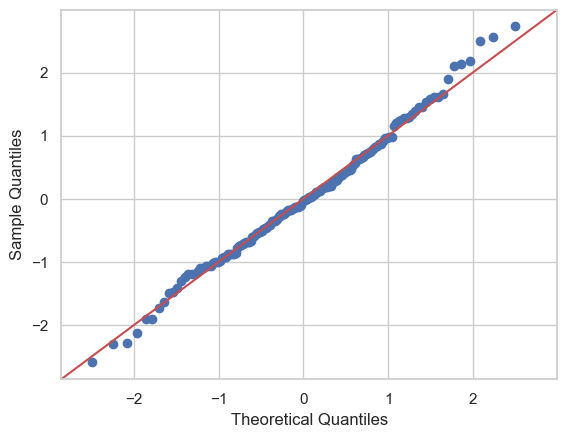

array([49, 70,  1, 19, 56])

In [7]:
# 学生作答区：以 log 模型为例检查诊断图
fitted = model_log.fittedvalues
resid = model_log.resid
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.show()

influence = model_log.get_influence()
cooks_d = influence.cooks_distance[0]
np.argsort(cooks_d)[-5:]


## 8. 模型评估

比较原始模型和 log 模型的 `R²`、残差图和解释性。

**学生作答区：**

1. `R²` 是否能证明模型正确？
2. 一个模型 p 值显著但 `R²` 不高时应如何解释？
3. 你会选择哪个模型作为主要报告？为什么？


1. 不能，$R^2$仅反映变异解释比例，无法验证模型设定、因果性与回归前提是否成立；
2. p 显著说明自变量的预测效应统计学可信，$R^2$低说明该自变量只能解释小部分因变量变异，仍有大量其他影响因素；
3. 选 log-log 模型，因其$R^2$更高、残差满足方差齐性假设、适配偏态医学指标的分布特征，统计合理性与实际可解释性更强

In [8]:
# 学生作答区：比较模型表现
print("Raw R-squared:", model_raw.rsquared)
print("Log R-squared:", model_log.rsquared)


Raw R-squared: 0.1051908461693365
Log R-squared: 0.21871021984404482


## 9. 结果报告

请写一段 120 到 180 字的结果报告，包含描述性结果、相关系数及 95% CI、回归斜率及 95% CI、p 值、`R²`、假设检查结论和生物医学解释。

本研究纳入160名社区成年人，研究低度炎症指标 CRP 是否与胰岛素抵抗水平 HOMA-IR 有关，测量得到的CRP与HOMA-IR数据均呈右偏分布，经对数转换后满足线性回归前提。简单线性模型分析得到log-CRP与log-HOMA-IR中等正向相关，$r=0.468$，95%CI [0.337, 0.581]，$p<0.001$。对数处理后回归模型斜率为0.354，95%CI不含0，$p<0.001$，调整后$R^2=0.219$，较原始模型拟合效果更好；残差检验提示对数模型方差齐性、分布更稳定。统计学结果提示低度炎症标志物CRP与胰岛素抵抗指标HOMA-IR存在稳定正向关联，CRP水平每升高1%，胰岛素抵抗水平平均上升0.354%，说明慢性低度炎症可能参与机体胰岛素抵抗的发生发展。
